
# Crochet tonnetz

I would like to make a better version of [](fig:Jan26_torus_1), now I have a pattern I am more content with. This involves mapping the following triangulation onto a torus.

:::{embed} #fig:tonnetz-grid
:::

Below is some code that will do this, along with its output pattern. Parameters[^prams] $R=5$, $r=2$, $w=0.4$, $h=0.4$ have been chosen fairly arbitrarily and may need to change

[^prams]: C.f. [](#CT) for what these do.

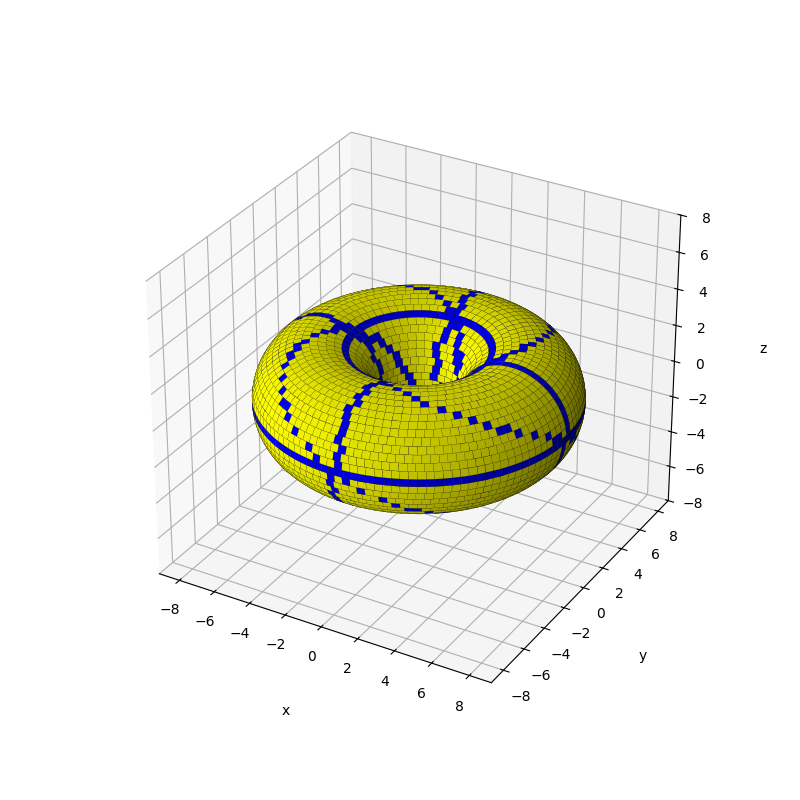

Row,Stitch count
0,31
1,32
2,33
3,35
4,38
5,41
6,45
7,50
8,55
9,61


In [2]:
from tabulate import tabulate

import numpy as np

from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS, same_color
%matplotlib ipympl

R = 5
r = 2
w = 0.4
h = 0.4

# Pattern instructions
N = round(r * np.pi/h)
st_count = [0]*(int(N)+1)
pattern = [0]*(int(N)+1)
row = [0]*(int(N)+1)
for n in range(int(N)+1):
    st_count[n]=round(2*np.pi*(R-r*np.cos(n*np.pi/int(N)))/w)
    row[n] = n #"Row "+str(n)+": "+str(st_count[n])+" st."

# Pattern model
fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection='3d')
ax.grid()

colours = [0]*(N+1)

for n in range(int(N)+1):
    colours[n]=['yellow' for i in range(st_count[n]+1)]
    for k in range(0,st_count[n]+1):
        theta = n*np.pi/N
        phi = (k+.5)*2*np.pi/st_count[n] # slight offset to better reflect crochet stitch distribution
        u = np.linspace((n-.5)*np.pi/N, (n+.5)*np.pi/N, 2)
        v = np.linspace((k)*2*np.pi/st_count[n], (k+1)*2*np.pi/st_count[n], 2)
        u, v = np.meshgrid(u, v)
        x = (R-r*np.cos(u))*np.cos(v)
        y = (R-r*np.cos(u))*np.sin(v)
        z = r*np.sin(u)
        tol=.45
        if n==N or n==round(N/3) or k==round(st_count[n]/4) or k==int(st_count[n]/2) or k==round(3*st_count[n]/4) or k==st_count[n]:
            colours[n][k] = 'blue'
        elif abs(4*phi-3*theta-np.pi)<tol or abs(4*(phi-np.pi/2)-3*theta-np.pi)<tol or abs(4*(phi-np.pi/2)-3*(theta-2*np.pi/3)+np.pi)<tol or abs(4*(phi-np.pi)-3*theta-np.pi)<tol or abs(4*(phi-3*np.pi/2)-3*theta-np.pi)<tol:
            colours[n][k] = 'blue'
        ax.plot_surface(x, y, z, color=colours[n][k], edgecolor='black', linewidth=.1)
        if n>0 and n<N:
            ax.plot_surface(x, -y, -z, color=colours[n][k], edgecolor='black', linewidth=.1)
# Axis labels
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

# Axis limits
ax.set(zlim=(-R-r,R+r))
    
ax.set_aspect('equal')

plt.show()


table = np.transpose([row, st_count])
pattern = tabulate(table,headers=["Row","Stitch count"],tablefmt="html")
display(pattern)